In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.gaussian_taylor import (
    FreeSpaceParaxial, 
    Biprism,
    Lens,
    run_to_end,
)
from temgym_core.utils import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_for, evaluate_gaussians_jax_scan


In [2]:
jax.config.update("jax_enable_x64", True)
W = 100e-9

Nx = Ny = 512
dx = W/Nx
dy = W/Ny
input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
input_extent = input_grid.extent
coords = input_grid.coords
X, Y = coords[:, 0].reshape(input_grid.shape), coords[:, 1].reshape(input_grid.shape)

distance = 1e-3
output_grid = Detector(z=distance, pixel_size=(dx * 4, dy * 4), shape=(Nx, Ny))
output_extent = output_grid.extent

voltage = 100e3
wavelength = energy2wavelength(voltage)  # 200 keV


In [3]:
w0 = 1e-8  # Beam waist

rays_in, wavelength, k0 = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=W / 2,
    waist_radius=w0,
    num_rays=1,
    normalization='flux',
)
rays_in = rays_in.to_vector()

R = 1e-5
lens = Lens(focal_length=R, z=0.0)

rays_out = run_to_end(rays_in, [lens])


/home/dl277493/Microscope-Calibration/TemGymCore/src/temgym_core/utils.py:311: RuntimeWarning: invalid value encountered in sqrt
  radius * np.sqrt((ii + 0.5) / (nb_samples - 0.5 * (np_boundary + 1)))


In [4]:
E_in = evaluate_gaussians_for(rays_out, input_grid)
E_gpu = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid)
E_scan = evaluate_gaussians_jax_scan(rays_out, input_grid)

assert jnp.allclose(E_in, E_gpu), "E_in and E_gpu are not the same"
assert jnp.allclose(E_in, E_scan), "E_in and E_scan are not the same"
assert jnp.allclose(E_gpu, E_scan), "E_gpu and E_scan are not the same"

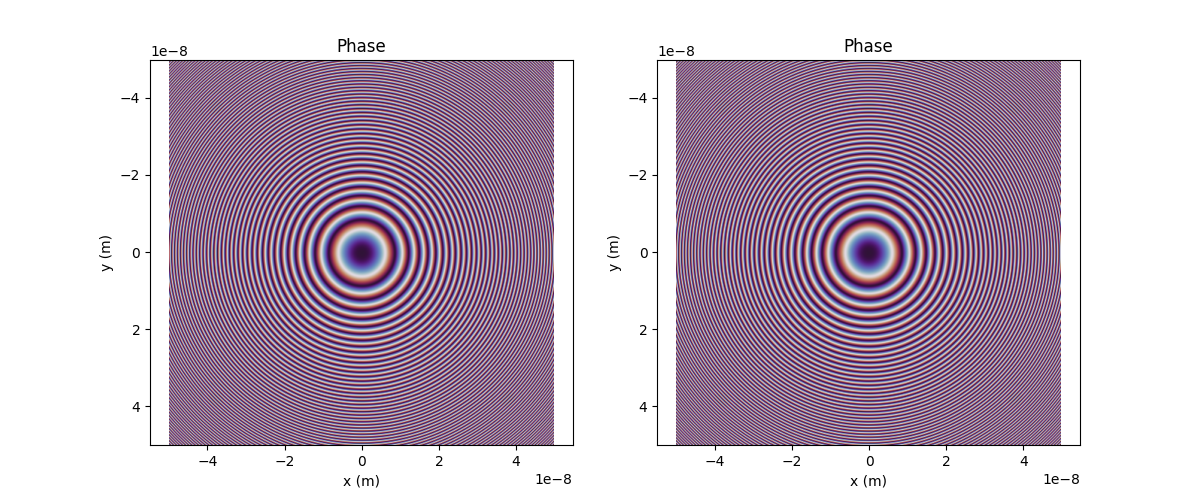

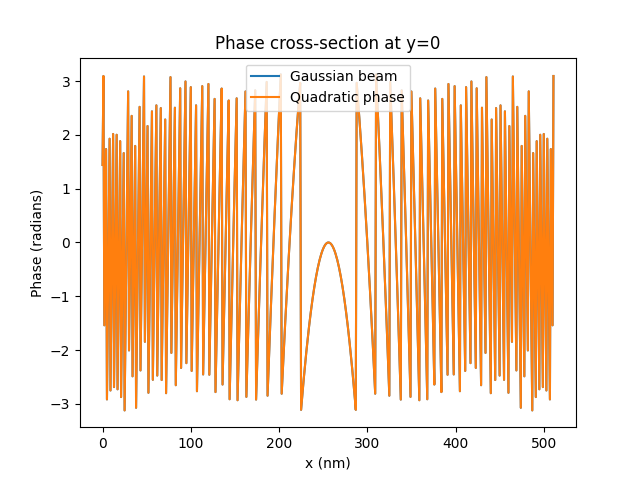

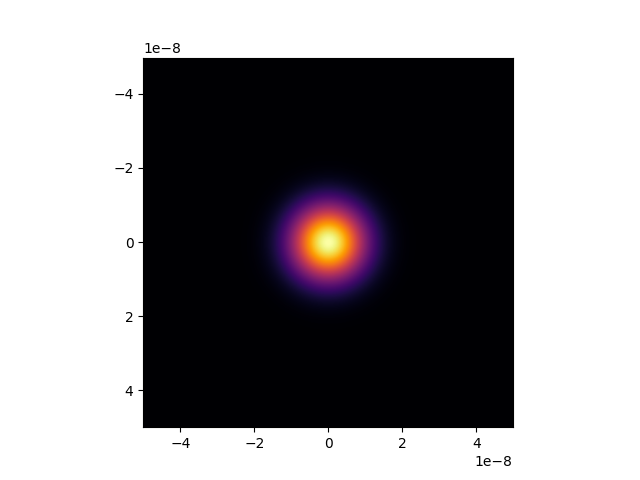

: 

In [ ]:
E_in = evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_grid)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Phase of gaussian beam
axs[0].imshow(np.angle(E_in), extent=input_extent, cmap='twilight')
axs[0].set_title('Phase')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].axis('equal')

quadratic_phase = jnp.exp(-1j * k0 / (2 * lens.focal_length) * (X**2 + Y**2))
axs[1].imshow(np.angle(quadratic_phase), extent=input_extent, cmap='twilight')
axs[1].set_title('Phase')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('y (m)')
axs[1].axis('equal')

# Plot cross section
plt.figure()
plt.plot(np.angle(E_in[Nx//2,:]), label='Gaussian beam')
plt.plot(np.angle(quadratic_phase[Nx//2,:]), label='Quadratic phase')
plt.xlabel('x (nm)')
plt.ylabel('Phase (radians)')
plt.legend()
plt.title('Phase cross-section at y=0')

plt.figure()
plt.imshow(np.abs(E_in), extent=input_extent, cmap='inferno')
